# Notebook 93 — restart-at-50 sensitivity

This notebook tests whether the first 50 frames are biasing the rest of the sequence by replaying the sequence from frame 50 onward and comparing it against the original full run on frames >= 50.

In [1]:
from pathlib import Path
import subprocess
import sys

from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / 'scripts').exists():
    ROOT = ROOT.parent
SCRIPT = ROOT / 'scripts' / 'evaluate_restart50_sensitivity.py'
OUT = ROOT / 'results' / 'notebook93_restart50_sensitivity'
SCRIPT, OUT

(PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_restart50_sensitivity.py'),
 PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/results/notebook93_restart50_sensitivity'))

In [2]:
completed = subprocess.run([sys.executable, str(SCRIPT)], check=True)
print(completed.returncode)

Loading cached localmax entries from /Users/grosbedou/PycharmProjects/NDORMS/results/notebook90_conditional_hough_patch/angle_profile_localmax_entries.pkl
# Notebook 93 — restart-at-50 sensitivity

This notebook tests whether the first 50 frames are biasing the rest of the sequence.
It compares existing full-sequence outputs restricted to frames >= 50 against a fresh replay restarted at frame 50.

## Key findings

- Baseline full-tail FL RMSE: 1.9925 mm
- Baseline restart@50 FL RMSE: 1.9940 mm
- Baseline final-alpha RMSE full-tail vs restart@50: 1.1714 deg -> 1.1593 deg
- Baseline raw-alpha drift from full tail after restart@50: 0.000000 deg
- Baseline final-alpha drift from full tail after restart@50: 0.1784 deg
- Best restart@50 FL RMSE among replayed variants: `nb90_mass10_gap4_reference` at 1.2541 mm

## Interpretation

- If raw alpha is unchanged but selected/final alpha move after restart@50, the early frames are affecting the stateful parts of the pipeline, not the per-frame Hou

In [3]:
display(Markdown((OUT / 'notebook93_summary.md').read_text()))

# Notebook 93 — restart-at-50 sensitivity

This notebook tests whether the first 50 frames are biasing the rest of the sequence.
It compares existing full-sequence outputs restricted to frames >= 50 against a fresh replay restarted at frame 50.

## Key findings

- Baseline full-tail FL RMSE: 1.9925 mm
- Baseline restart@50 FL RMSE: 1.9940 mm
- Baseline final-alpha RMSE full-tail vs restart@50: 1.1714 deg -> 1.1593 deg
- Baseline raw-alpha drift from full tail after restart@50: 0.000000 deg
- Baseline final-alpha drift from full tail after restart@50: 0.1784 deg
- Best restart@50 FL RMSE among replayed variants: `nb90_mass10_gap4_reference` at 1.2541 mm

## Interpretation

- If raw alpha is unchanged but selected/final alpha move after restart@50, the early frames are affecting the stateful parts of the pipeline, not the per-frame Hough math.
- If restart@50 improves MATLAB parity, that means some remaining gap is initialization/history sensitivity rather than a framewise mathematical mismatch.

- Summary CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook93_restart50_sensitivity/restart50_summary.csv`
- Per-frame drift CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook93_restart50_sensitivity/restart50_per_frame.csv`
- Summary plot: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook93_restart50_sensitivity/restart50_summary.png`


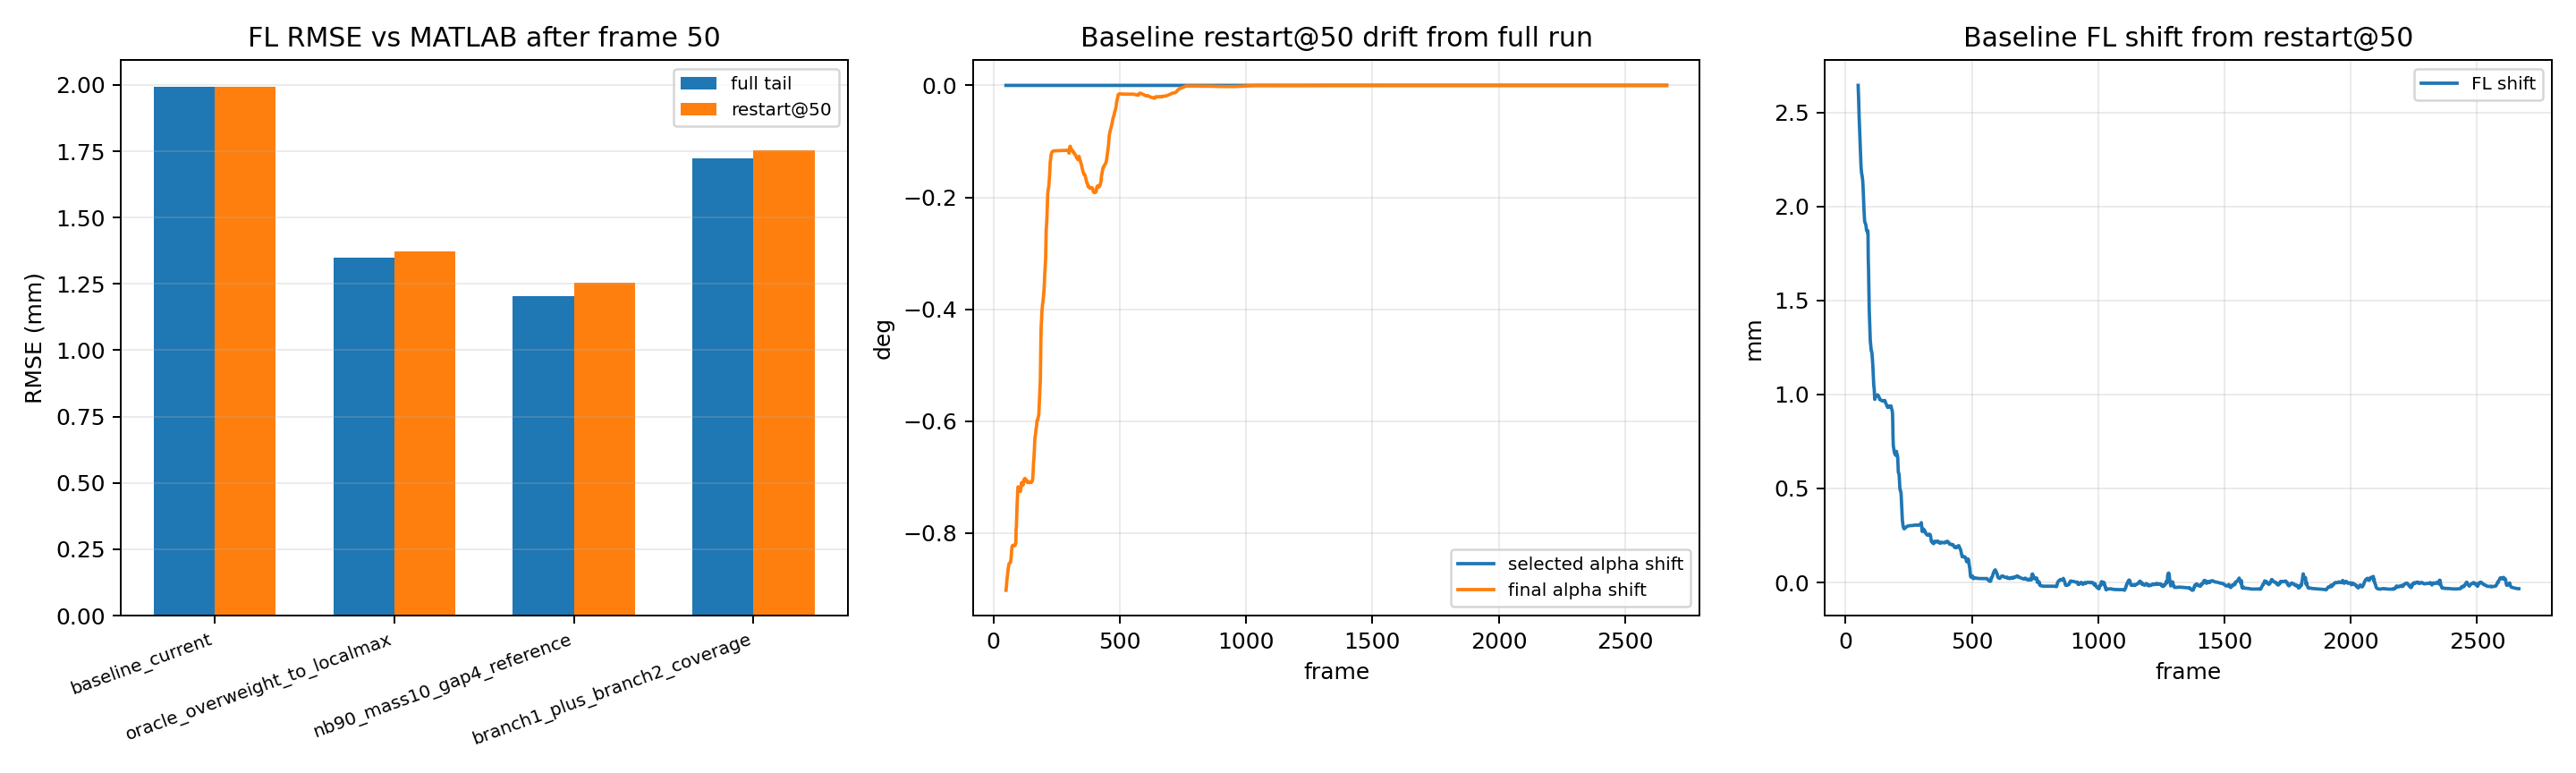

In [4]:
display(Image(filename=str(OUT / 'restart50_summary.png')))